In [1]:
# ========================================
# INFERENCE ON LARGE TIFF FILE
# ========================================

import os
import cv2
from rasterio.windows import Window
from rasterio.transform import from_bounds
import geopandas as gpd
from shapely.geometry import shape
from rasterio import features
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# ========================================
# CONFIGURATION
# ========================================
tiff_file = "test23.tif"
inference_tiff_path = f"../data/tifs_for_inference/{tiff_file}"
output_dir = "../inference_results"
os.makedirs(output_dir, exist_ok=True)

# Path to your saved model
model_name = "path_segmentation_model_lr0.0005.pth"
model_path = f"../trained_models/{model_name}"

# Model settings (should match training)
INFERENCE_TILE_SIZE = 4096  # Process in large chunks
TARGET_SIZE = 128  # Size model was trained on
BATCH_SIZE = 16  # Process multiple tiles at once

# Prediction threshold
PREDICTION_THRESHOLD = 0.5

In [3]:
# ========================================
# LOAD TRAINED MODEL
# ========================================

import torch
import segmentation_models_pytorch as smp


# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Recreate the EXACT same model architecture as training
model = smp.Unet(
    encoder_name="efficientnet-b0",      # Must match training
    encoder_weights=None,          # Don't load ImageNet weights, we have our own
    in_channels=4,                 # Must match training
    classes=1,                     # Must match training
    activation=None                # Must match training
)

# Load the trained weights
model.load_state_dict(torch.load(model_path, map_location=device))

# Move model to device and set to evaluation mode
model = model.to(device)
model.eval()

print("✓ Model loaded successfully!")

/Users/moritzbaumann/Coding/Ocean-Hackathon/BRE01/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
✓ Model loaded successfully!


In [4]:
# ========================================
# INFERENCE FUNCTION
# ========================================
def predict_tile(img_tile, model, device, target_size=TARGET_SIZE):
    """Predict on a single tile"""
    # Downscale to model input size
    img_downscaled = np.zeros(
        (4, target_size, target_size), dtype=img_tile.dtype)
    for band in range(4):
        img_downscaled[band] = cv2.resize(
            img_tile[band],
            (target_size, target_size),
            interpolation=cv2.INTER_LINEAR
        )

    # Normalize (same as training)
    img_tensor = torch.tensor(img_downscaled, dtype=torch.float32).unsqueeze(0)
    img_tensor = img_tensor / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406, 0.5]).view(1, 4, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225, 0.25]).view(1, 4, 1, 1)
    img_tensor = (img_tensor - mean) / std

    # Predict
    with torch.no_grad():
        img_tensor = img_tensor.to(device)
        pred = torch.sigmoid(model(img_tensor))
        pred = pred.cpu().numpy()[0, 0]

    # Upscale prediction back to original tile size
    pred_upscaled = cv2.resize(
        pred,
        (img_tile.shape[2], img_tile.shape[1]),
        interpolation=cv2.INTER_LINEAR
    )

    return pred_upscaled


Processing ../data/tifs_for_inference/test23.tif...
Image dimensions: 17764 x 11009
CRS: EPSG:3857
Reading entire TIFF into memory...
Image shape: (4, 11009, 17764)
Running inference on full image...
Prediction shape: (11009, 17764)

Saving binary mask as GeoTIFF...
✓ Saved mask to: ../inference_results/predicted_mask.tif
Saving probability map as GeoTIFF...
✓ Saved probability map to: ../inference_results/predicted_probabilities.tif
Vectorizing predictions to line features...
⚠️  No paths detected in predictions!
  (Would have saved to: ../inference_results/predicted_paths.gpkg)

Creating visualization...


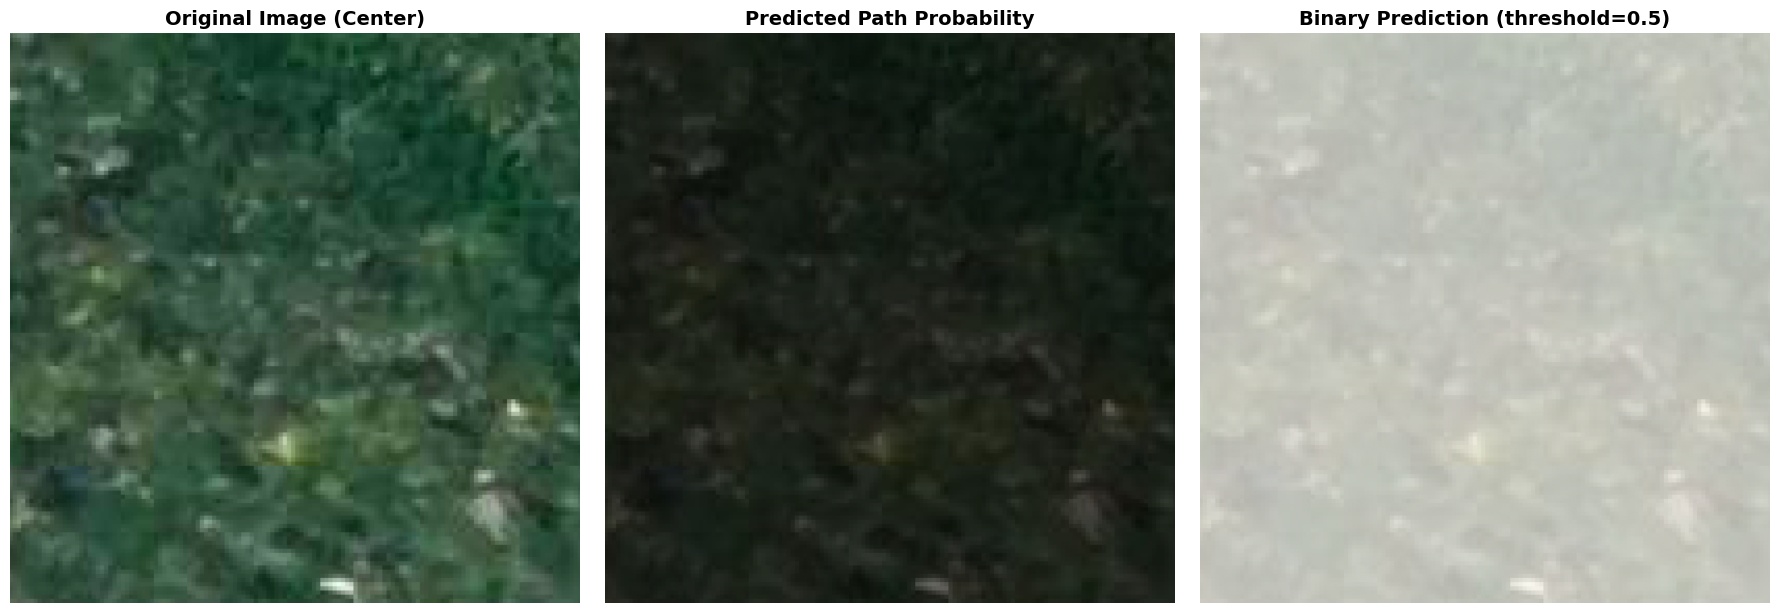

✓ Saved visualization to: ../inference_results/prediction_visualization.png

✓ INFERENCE COMPLETE!

Generated files:
  1. Binary mask (GeoTIFF):     ../inference_results/predicted_mask.tif
  2. Probability map (GeoTIFF): ../inference_results/predicted_probabilities.tif
  3. Vector paths (GPKG):       ../inference_results/predicted_paths.gpkg
  4. Visualization (PNG):       ../inference_results/prediction_visualization.png

You can open the GeoTIFF and GPKG files in QGIS for analysis!


In [ ]:
# ========================================
# PROCESS ENTIRE TIFF AT ONCE
# ========================================
from skimage.morphology import skeletonize

print(f"\nProcessing {inference_tiff_path}...")

with rasterio.open(inference_tiff_path) as src:
    print(f"Image dimensions: {src.width} x {src.height}")
    print(f"CRS: {src.crs}")

    # Read the entire image at once
    print("Reading entire TIFF into memory...")
    img_full = src.read()  # Shape: (4, height, width)
    print(f"Image shape: {img_full.shape}")

    # Predict on the entire image
    print("Running inference on full image...")
    full_prediction = predict_tile(img_full, model, device, TARGET_SIZE)
    print(f"Prediction shape: {full_prediction.shape}")

    # ========================================
    # SAVE 1: BINARY MASK AS GEOTIFF
    # ========================================
    print("\nSaving binary mask as GeoTIFF...")
    binary_mask = (full_prediction > PREDICTION_THRESHOLD).astype(np.uint8)

    output_mask_path = os.path.join(output_dir, "predicted_mask.tif")
    with rasterio.open(
        output_mask_path,
        'w',
        driver='GTiff',
        height=binary_mask.shape[0],
        width=binary_mask.shape[1],
        count=1,
        dtype=binary_mask.dtype,
        crs=src.crs,
        transform=src.transform,
        compress='lzw'
    ) as dst:
        dst.write(binary_mask, 1)

    print(f"✓ Saved mask to: {output_mask_path}")

    # ========================================
    # SAVE 2: PROBABILITY MAP AS GEOTIFF
    # ========================================
    print("Saving probability map as GeoTIFF...")
    output_prob_path = os.path.join(output_dir, "predicted_probabilities.tif")

    # Scale to 0-255 for smaller file size
    prob_scaled = (full_prediction * 255).astype(np.uint8)

    with rasterio.open(
        output_prob_path,
        'w',
        driver='GTiff',
        height=prob_scaled.shape[0],
        width=prob_scaled.shape[1],
        count=1,
        dtype=prob_scaled.dtype,
        crs=src.crs,
        transform=src.transform,
        compress='lzw'
    ) as dst:
        dst.write(prob_scaled, 1)

    print(f"✓ Saved probability map to: {output_prob_path}")

    # ========================================
    # SAVE 3: VECTORIZE TO SHAPEFILE/GPKG
    # ========================================
    print("Vectorizing predictions to line features...")

    # Thin the mask to centerline (optional but recommended for paths)
    skeleton = skeletonize(binary_mask).astype(np.uint8)

    # Extract shapes (polygons)
    mask_shapes = list(features.shapes(skeleton, transform=src.transform))

    # Convert to GeoDataFrame
    geometries = []
    values = []
    for geom, value in mask_shapes:
        if value == 1:  # Only path pixels
            geometries.append(shape(geom))
            values.append(value)

    # Define output path before the if statement
    output_vector_path = os.path.join(output_dir, "predicted_paths.gpkg")

    if len(geometries) > 0:
        gdf = gpd.GeoDataFrame(
            {'value': values},
            geometry=geometries,
            crs=src.crs
        )

        # Save as GeoPackage
        gdf.to_file(output_vector_path, driver="GPKG")
        print(f"✓ Saved vector paths to: {output_vector_path}")
        print(f"  Total path features: {len(gdf)}")
    else:
        print("⚠️  No paths detected in predictions!")
        print(f"  (Would have saved to: {output_vector_path})")

        # ========================================
        # SAVE 4: VISUALIZATION - PATH OVERLAY ON IMAGE
        # ========================================
        print("\nCreating visualization...")

        # Read a portion of the image for visualization (full image would be too large)
        # Adjust if image is smaller
        vis_size = min(2048, src.width, src.height)
        center_x, center_y = src.width // 2, src.height // 2

        # Calculate window boundaries
        x_start = max(0, center_x - vis_size//2)
        y_start = max(0, center_y - vis_size//2)
        x_end = min(src.width, x_start + vis_size)
        y_end = min(src.height, y_start + vis_size)

        vis_window = Window(x_start, y_start, x_end - x_start, y_end - y_start)

        img_vis = src.read([1, 2, 3], window=vis_window)  # RGB bands
        img_vis = np.moveaxis(img_vis, 0, -1)

        # Normalize for display
        img_vis = (img_vis - img_vis.min()) / \
            (img_vis.max() - img_vis.min() + 1e-8)

        # Get corresponding mask portion
        mask_vis = full_prediction[y_start:y_end, x_start:x_end]

        # Create overlay
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Original image
        axes[0].imshow(img_vis)
        axes[0].set_title("Original Image (Center)",
                          fontsize=14, fontweight='bold')
        axes[0].axis('off')

        # Prediction probability
        axes[1].imshow(img_vis)
        axes[1].imshow(mask_vis, cmap='hot', alpha=0.6, vmin=0, vmax=1)
        axes[1].set_title("Predicted Path Probability",
                          fontsize=14, fontweight='bold')
        axes[1].axis('off')

        # Binary prediction
        axes[2].imshow(img_vis)
        binary_vis = (mask_vis > PREDICTION_THRESHOLD).astype(float)
        axes[2].imshow(binary_vis, cmap='Reds', alpha=0.7, vmin=0, vmax=1)
        axes[2].set_title(f"Binary Prediction (threshold={PREDICTION_THRESHOLD})",
                          fontsize=14, fontweight='bold')
        axes[2].axis('off')

        plt.tight_layout()
        output_vis_path = os.path.join(
            output_dir, "prediction_visualization.png")
        plt.savefig(output_vis_path, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"✓ Saved visualization to: {output_vis_path}")

# File is now closed

print("\n" + "="*60)
print("✓ INFERENCE COMPLETE!")
print("="*60)
print(f"\nGenerated files:")
print(f"  1. Binary mask (GeoTIFF):     {output_mask_path}")
print(f"  2. Probability map (GeoTIFF): {output_prob_path}")
print(f"  3. Vector paths (GPKG):       {output_vector_path}")
print(f"  4. Visualization (PNG):       {output_vis_path}")
print("\nYou can open the GeoTIFF and GPKG files in QGIS for analysis!")

Creating full image visualization with vector paths...


DataSourceError: ../inference_results/predicted_paths.gpkg: No such file or directory

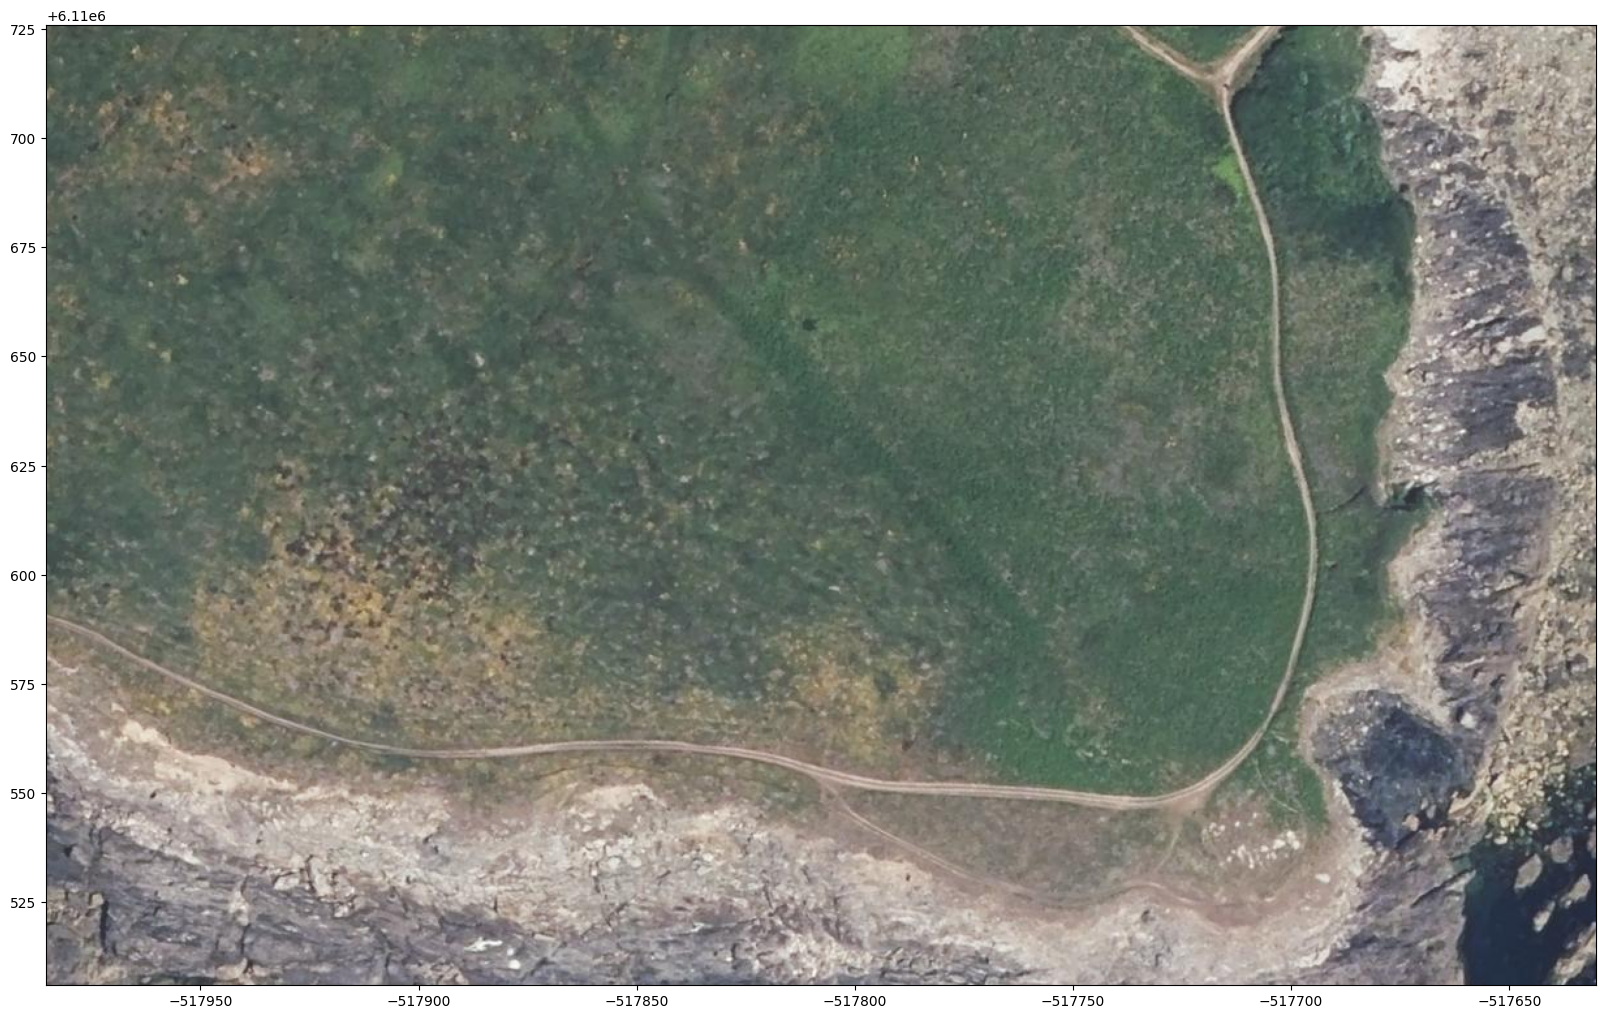

In [6]:
# ========================================
# PLOT FULL IMAGE WITH VECTOR PATHS
# ========================================
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.plot import show

print("Creating full image visualization with vector paths...")

# Create figure
fig, ax = plt.subplots(figsize=(20, 20))

# Open and display the original TIFF
with rasterio.open(inference_tiff_path) as src:
    # Display RGB bands (bands 1, 2, 3)
    show(src.read([1, 2, 3]), transform=src.transform, ax=ax)

# Load and overlay the vector paths
vector_path = os.path.join(output_dir, "predicted_paths.gpkg")
gdf = gpd.read_file(vector_path)

# Plot the vector paths on top
gdf.plot(ax=ax, color='red', linewidth=0.5, alpha=0.7)

ax.set_title("Full TIFF with Predicted Paths", fontsize=16, fontweight='bold')
ax.axis('off')

plt.tight_layout()
output_full_vis = os.path.join(output_dir, "full_image_with_paths.png")
plt.savefig(output_full_vis, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved full visualization to: {output_full_vis}")